In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from preprocessing import my_preprocessor, my_tokenizer
from helpfuncties import load_dataset

In [2]:
df = load_dataset()
X_text = df["Omschrijving"].astype(str)
y = df["Product"]

In [ ]:
def make_domain_features(series: pd.Series) -> pd.DataFrame:
    s = series.fillna("").str.lower()

    auto_terms = r"auto|vehicle|car|dealership|dealer|auto loan|car loan|repossession|repo|drive time|honda|toyota|nissan|ford|gm|chrysler|santander|westlake|ally"
    bureau_terms = r"equifax|experian|transunion|credit report|credit file|inquiry|inquiries|report xxxx|fcra"
    collection_terms = r"debt|collection|collector|collect|fdcpa|validation|collection agency|attempting collect|owe|recovery"
    fraud_terms = r"identity theft|fraud|unauthorized|not mine|stolen identity"

    return pd.DataFrame({
        "has_auto_terms": s.str.contains(auto_terms, regex=True).astype(int),
        "has_creditbureau_terms": s.str_contains(bureau_terms, regex=True).astype(int) if hasattr(s, "str") else s.str.contains(bureau_terms, regex=True).astype(int),
        "has_collection_terms": s.str.contains(collection_terms, regex=True).astype(int),
        "fraud_flag": s.str.contains(fraud_terms, regex=True).astype(int),
    })

In [4]:
def make_domain_features(series: pd.Series) -> pd.DataFrame:
    s = series.fillna("").str.lower()

    auto_terms = r"auto|vehicle|car|dealership|dealer|auto loan|car loan|repossession|repo|drive time|honda|toyota|nissan|ford|gm|chrysler|santander|westlake|ally"
    bureau_terms = r"equifax|experian|transunion|credit report|credit file|inquiry|inquiries|report xxxx|fcra"
    collection_terms = r"debt|collection|collector|collect|fdcpa|validation|collection agency|attempting collect|owe|recovery"
    fraud_terms = r"identity theft|fraud|unauthorized|not mine|stolen identity"

    return pd.DataFrame({
        "has_auto_terms": s.str.contains(auto_terms, regex=True).astype(int),
        "has_creditbureau_terms": s.str.contains(bureau_terms, regex=True).astype(int),
        "has_collection_terms": s.str.contains(collection_terms, regex=True).astype(int),
        "fraud_flag": s.str.contains(fraud_terms, regex=True).astype(int),
    })

domain_df = make_domain_features(X_text)

# Combineer tekst + features in één DataFrame
X_full = pd.concat([X_text.rename("Omschrijving"), domain_df], axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.3, random_state=42, stratify=y
)

In [6]:
text_tfidf = TfidfVectorizer(
    preprocessor=my_preprocessor,
    tokenizer=my_tokenizer,
    analyzer="word",
    token_pattern=None,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2"
)

feature_cols = ["has_auto_terms", "has_creditbureau_terms", "has_collection_terms", "fraud_flag"]

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_tfidf, "Omschrijving"),
        ("flags", StandardScaler(with_mean=False), feature_cols),
    ]
)

In [7]:
svc_pipeline = Pipeline([
    ("features", preprocessor),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

In [8]:
param_grid = {
    "clf__C": [0.1, 0.5, 1.0, 2.0, 5.0],
    "features__text__ngram_range": [(1, 1), (1, 2)],  # unigrams vs uni+bi
    "features__text__max_df": [0.9, 0.95],
    "features__text__min_df": [2, 3],
}

grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Start GridSearch LinearSVC + domeinfeatures...")
grid.fit(X_train, y_train)

print("\nBeste parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

Start GridSearch LinearSVC + domeinfeatures...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Beste parameters:
{'clf__C': 1.0, 'features__text__max_df': 0.9, 'features__text__min_df': 3, 'features__text__ngram_range': (1, 2)}


In [9]:
cv_scores = cross_val_score(
    best_model,
    X_train, y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
print(f"\nCV F1-macro (train): {cv_scores.mean():.3f}")
print("Per fold:", cv_scores)


CV F1-macro (train): 0.835
Per fold: [0.83693292 0.84951412 0.8156464  0.83910368 0.83431882]


In [12]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"\nAccuracy test: {acc:.3f}")
print(f"F1-macro test: {f1_macro:.3f}")
print(f"F1-weighted test: {f1_weighted:.3f}")

print("\nClassification report LinearSVC + domeinfeatures:")
print(classification_report(y_test, y_pred, digits=3))


Accuracy test: 0.861
F1-macro test: 0.837
F1-weighted test: 0.859

Classification report LinearSVC + domeinfeatures:
                    precision    recall  f1-score   support

      Bankrekening      0.885     0.861     0.873       446
Consumentenkrediet      0.738     0.616     0.672       284
        Creditcard      0.833     0.842     0.838       564
         Hypotheek      0.922     0.943     0.932       994
           Incasso      0.844     0.875     0.859      1223
Kredietregistratie      0.852     0.839     0.846       934

          accuracy                          0.861      4445
         macro avg      0.846     0.829     0.837      4445
      weighted avg      0.859     0.861     0.859      4445



[[ 384    2   32   11   10    7]
 [   6  175   17   15   52   19]
 [  20    9  475    7   33   20]
 [  13   11    5  937   12   16]
 [   9   23   19   28 1070   74]
 [   2   17   22   18   91  784]]


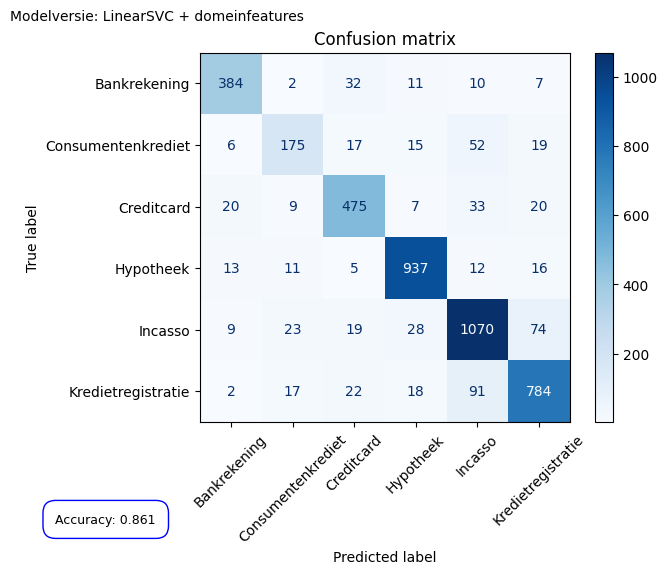

In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: LinearSVC + domeinfeatures", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {acc:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_linsvc_met_domeinfeatures.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()